# Assignment 1 — Univariate and Multivariate Statistics

**FinTech 545 — Quantitative Risk Management**

---

Each problem follows the required three-part structure: a **Prediction** made from
plots and moments *before* any model is fitted, the **Fit**, and a
**Reconciliation** that says whether the fit agreed and, where it did not, what
had been missed.

Every definition used here — the moment estimators, the AICc penalty and its
parameter count, the partitioned conditional-distribution result, the ACF/PACF
identification rule, the OLS assumption numbering — is taken from the Week 01 and
Week 02 slides and cited inline at the point of use, so nothing below rests on a
convention I chose myself.

### Code layout

The computation lives in six plain Python files next to this notebook rather than
in the notebook itself, so each problem can be run and checked independently:

| file | contents |
|---|---|
| `common.py` | shared helpers: moment estimators (Week 01 §4), AICc (Week 02 §5.3), plot style |
| `problem1.py` … `problem5.py` | one module per problem, each runnable on its own |

Every module runs standalone (`python problem3.py`) and prints exactly the numbers
quoted in the write-up below. The cells here import them, so nothing is computed
twice and no number in the prose is typed by hand. `README.md` lists the commands
to reproduce everything.

In [1]:
# Standard imports and the shared helper module. Every problem module is written
# to be importable, so the notebook never recomputes anything itself.
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import common
import problem1, problem2, problem3, problem4, problem5

common.use_style()          # quiet, print-friendly plot style
pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 20)

print("modules loaded")

modules loaded


---

# Problem 1 — Reading the Shape of a Sample

`problem1.csv` holds a single series `x` of 1000 observations. The scale (sd
$\approx 0.0098$) suggests daily returns, which matters because it tells us which
tail to care about.

## Predict

Week 01 §3.2 defines the reported skewness and kurtosis as the standardized
quantities $\mu_3/\sigma^3$ and $\mu_4/\sigma^4 - 3$, so kurtosis is always
**excess** kurtosis (Normal $= 0$). §4.2 gives the variance estimator dividing by
$n-1$, and §4.3 gives the bias-corrected third and fourth moment estimators; those
bias-corrected forms are the headline numbers below. §4.4 warns that packages
differ on this and says to check rather than assume, so all three variants are
printed — on this data they span $0.018$ on a value of $2.36$, and nothing here
depends on the choice.

$$\text{skewness} = -0.6698, \qquad \text{excess kurtosis} = +2.3576$$

Under the null of normality $\widehat{\text{skew}} \sim N(0, 6/n)$ and
$\widehat{\text{exkurt}} \sim N(0, 24/n)$, giving standard errors of $0.0775$ and
$0.1549$. So the skewness sits **8.65 standard errors** below zero and the excess
kurtosis **15.22** above it. Neither is sampling noise.

Read together: **the distribution is left-skewed and fat-tailed.**

A feasibility check first, from Week 01 §6: for any distribution
$\text{kurtosis} \ge \text{skewness}^2 + 1$, i.e. excess kurtosis
$\ge \text{skew}^2 - 2 = -1.5513$ here. Observed $+2.3576$ clears it, so the pair
is admissible and not a calculation error.

### (a) Which distributions could have produced this, and which are ruled out

Week 01 §5 covers four families — Normal, Lognormal, Student's $t$, and Normal
Inverse Gaussian — and §6 Table 6 is the course's own skew/kurtosis filter over
them:

| sample skew | sample excess kurtosis | candidate families |
|---|---|---|
| $\approx 0$ | $\approx 0$ | Normal |
| $\approx 0$ | $> 0$ | Student's $t$, symmetric NIG |
| $\ne 0$ | $> 0$ | **NIG, skewed $t$, generalized hyperbolic** |
| $> 0$ | $> 0$, positive support | Lognormal |

This sample has skew $\ne 0$ and excess kurtosis $> 0$, so it lands in the third
row. Taking the four families one at a time, each rejection naming the single
moment responsible:

| distribution | moments it can produce | verdict |
|---|---|---|
| **Normal** | skew $=0$, exkurt $=0$ | **ruled out by excess kurtosis** — $+2.36$ is 15 se above the 0 it requires, and §6 notes no choice of $\mu$ and $\sigma$ changes that |
| **Lognormal** | skew $>0$, support $x>0$ | **ruled out by skewness** — sign is wrong. Also excluded by support: the sample has negative values |
| **Student's $t$** | skew $=0$, exkurt $>0$ | kurtosis **plausible**, but the $t$ is **symmetric**. §5.5: "the $t$ gives us fat tails and nothing else" — it cannot make skew $-0.67$ |
| **NIG** | skew and exkurt both free | **plausible** — the only §5 family carrying both, and Table 6's answer for this row |

The NIG claim is checkable rather than a matter of trust. §5.5 Table 5 gives its
skewness as $3\beta/(\alpha\sqrt{\delta\gamma})$ and excess kurtosis as
$\frac{3}{\delta\gamma}(1 + 4\beta^2/\alpha^2)$ with
$\gamma = \sqrt{\alpha^2-\beta^2}$. Solving those two equations for the observed
pair returns $\alpha = 13.17$, $\beta = -3.84$, $\delta = 0.135$, reproducing
skew $-0.6698$ and excess kurtosis $+2.3576$ exactly. Note $\beta < 0$: Table 5's
skewness follows the sign of $\beta$, so a negative skew *requires* it.

**Prediction, committed:** the Normal and Lognormal are impossible; the symmetric
$t$ can reach the kurtosis but not the skew; the **NIG** is the family that fits.
Table 6 is described in the slides as "a filter, not a decision" — it says which
families *can* reproduce the shape, and choosing among survivors "requires a
likelihood comparison or a look at the tail itself." Part (c) does both.

**A prediction about the fit:** forcing a Normal on this sample by matching the
first two moments means $\sigma$ must stretch to cover fat tails, so I expect
materially **more** than the nominal 10 observations below its 1% quantile.

In [2]:
# (a) Moments per Week 01 s4 (all three estimator variants), the s6 feasibility
#     check, the normality screen, and numerical verification that the NIG can
#     actually reach this (skew, excess kurtosis) pair.
x1 = common.load("problem1")["x"].to_numpy()
m1 = problem1.part_a(x1)


Problem 1(a) -- first four moments
  n                 = 1000
  mean              =  0.001104
  variance (ddof=1) =  9.624822e-05
  std dev           =  0.009811
  skewness          = -0.6698   [bias-corrected, Week 01 s4.3]
  excess kurtosis   =  2.3576   [bias-corrected]

  Estimator variants (Week 01 s4.4 -- check, do not assume):
    skew   : bias-corrected -0.6698   population form -0.6688
    exkurt : bias-corrected +2.3576   population form +2.3398
             s4.3 expression over s^4 +2.3446
    The three exkurt variants span 0.0178 on a value of 2.36, so
    nothing below depends on the choice.

  Feasibility check (Week 01 s6): excess kurtosis must be >= skew^2 - 2 = -1.5513
    observed +2.3576 -> admissible

  Under H0: Normal --  se(skew) = 0.0775, se(exkurt) = 0.1549
    skew            : -8.65 standard errors from 0
    excess kurtosis : +15.22 standard errors from 0
    Jarque-Bera     : JB = 302.68, p = 1.882e-66

  Moment screen -- Week 01 Table 6 applied to this sa

## Fit and reconcile

The Normal is fitted by matching mean and variance: $\hat\mu = 0.001104$,
$\hat\sigma = 0.009811$.

### (b) Observations below the fitted Normal's 1% quantile

Its 1% quantile is $-0.021719$.

| | count |
|---|---|
| **observed** below that quantile | **26** |
| **expected** if truly Normal | **10** |

$2.6\times$ as many as there should be. Under a correctly specified Normal the
count is $\text{Binomial}(1000, 0.01)$, and $P(\ge 26) = 1.6\times10^{-5}$.

The pattern deepens further out — the signature of a tail problem rather than a
location or scale problem:

| tail level $p$ | Normal's quantile | observed below | expected |
|---|---|---|---|
| 5.0% | $-0.01503$ | 50 | 50.0 |
| 2.5% | $-0.01812$ | 40 | 25.0 |
| **1.0%** | $\mathbf{-0.02172}$ | **26** | **10.0** |
| 0.5% | $-0.02417$ | 18 | 5.0 |
| 0.1% | $-0.02921$ | 9 | 1.0 |

At 5% the fit is exact. The error appears near 2.5% and grows without bound; by
0.1% the Normal is wrong by a factor of nine.

In [3]:
# (b) Fit the Normal by moment matching; count exceedances of its 1% quantile
#     across the left tail, the right tail, and the centre.
fit1 = problem1.part_b(x1, m1)


Problem 1(b) -- exceedances of the fitted Normal's 1% quantile
  Fitted Normal: mu = 0.001104, sigma = 0.009811
  1% quantile of that Normal      = -0.021719
  OBSERVED number of x below it   = 26
  EXPECTED number if truly Normal = 10.0
  ratio observed / expected       = 2.60x
  Binomial test P(>= 26 of 1000 at p=0.01) = 1.559e-05

  Exceedance counts across the left tail
  --------------------------------------------------------------------
        p    Normal q   empirical q   observed  expected
  --------------------------------------------------------------------
    0.001    -0.02921      -0.04325          9       1.0
    0.005    -0.02417      -0.03479         18       5.0
     0.01    -0.02172      -0.02699         26      10.0
    0.025    -0.01812      -0.02196         40      25.0
     0.05    -0.01503      -0.01495         50      50.0
  --------------------------------------------------------------------

  Right tail, for contrast
  -------------------------------------

### (c) What the fitted Normal gets wrong, where, and in which direction

Three failures, in three different directions.

**1. The left tail — understated, and this is the one that matters.**
The Normal's 1% quantile is $-0.02172$; the sample's is $-0.02699$, $1.24\times$
further from the mean. Equivalently the Normal assigns probability $0.0021$ to a
loss that actually happens 1% of the time — **understating its frequency by a
factor of 4.8**. Equivalently, a 99% VaR read off this fitted Normal is **19.5%
too small** ($0.02172$ against the empirical $0.02699$), and the gap widens at
higher confidence. **The model is optimistic about losses.**

**2. The right tail — overstated.** Above the 95th percentile there are 34
observations where 50 are expected; above the 99th, 6 where 10 are expected. The
fitted Normal is too generous about gains. This is the skewness surfacing: a
symmetric model fitted to an asymmetric sample splits the difference, ending too
thin on the left and too thick on the right. Kurtosis alone would not have
revealed it, which is why the skew had to be read too.

**3. The centre — overstated peak.** 56.6% of the sample falls inside the fitted
Normal's IQR against the 50.0% a true Normal gives. Because $\sigma$ was inflated
to cover the extremes, the density is too wide through the shoulders, so too much
real data piles up inside. A fat-tailed sample forced into a Normal is always
simultaneously over-peaked *and* under-tailed.

### The likelihood comparison §6 asks for

| model | $\ell$ | $k$ | AICc | $\Delta$AICc |
|---|---|---|---|---|
| **NIG** | 3253.36 | 4 | **−6498.69** | **0.00** |
| Student $t$ | 3244.76 | 3 | −6483.49 | 15.19 |
| Normal | 3205.85 | 2 | −6407.69 | 91.00 |

(Lognormal omitted: its support is $x>0$ and the sample has negative values.)

The ranking matches the moment screen exactly — the family carrying both skew and
kurtosis wins, the symmetric fat-tailed family is next, the Normal last by 91
AICc units. The fitted NIG has $\beta = -35.84 < 0$, as the negative sample skew
requires.

### Reconciliation

The prediction held in direction and roughly in size: I expected more than 10
observations below the 1% quantile, and there are 26. The family call held too —
Table 6 pointed at the NIG and the likelihood comparison confirmed it.

What the moments alone did **not** tell me:

- **How asymmetric the failure is.** I predicted a fat left tail; I did not
  anticipate the right tail coming out *thinner* than Normal (34 vs 50 at the 5%
  level). It follows directly from the negative skew, but I had been reading skew
  and kurtosis as two separate facts rather than as a joint statement about two
  tails moving in opposite directions.
- **Where the failure begins.** At 5% the Normal is exactly right. I had loosely
  expected smooth degradation from the centre out; instead it is essentially
  perfect to 5%, then fails progressively harder from about 2.5% inward. A model
  validated at 95% can look healthy while being unusable at 99%.
- **The over-peaked centre**, which I had not predicted at all though it is forced
  by the arithmetic of moment matching.

One caution I should carry, from §6: "treat the sample kurtosis as a signal about
direction and not as a number ... A sample excess kurtosis of 4 tells us the tails
are fat. It does not tell us they are twice as fat as a series that came in at 2."
So $+2.36$ should be read as *fat tails, confidently* — not as a precise
measurement, and the three estimator variants spanning $0.018$ is the least of the
uncertainty in it.


Problem 1(c) -- where the fitted Normal is wrong
  The Normal's 1% quantile is -0.02172; the sample's true 1%
  quantile is -0.02699, i.e. 1.24x as far from the mean.
  Put the other way: the Normal assigns probability 0.0021
  to a loss that actually happens 1% of the time -- it understates the
  frequency of that loss by a factor of 4.8.
  As a VaR magnitude: a 99% VaR read off this fitted Normal is
  19.5% too small (0.02172 against the empirical 0.02699).

  Likelihood comparison across the Week 01 s5 families
  (Lognormal omitted: support is x > 0, the sample has negatives)
          model  loglik  k     AICc  dAICc
      NIG (k=4) 3253.36  4 -6498.69   0.00
Student t (k=3) 3244.76  3 -6483.49  15.19
   Normal (k=2) 3205.85  2 -6407.69  91.00

  Fitted Student t : nu = 4.88, loc = 0.00165, scale = 0.00761
  Fitted NIG       : alpha = 134.19, beta = -35.84, delta = 0.01151, mu = +0.00429
    beta = -35.84 < 0, matching the negative sample skew, as
    s5.5 Table 5 requires (skewne

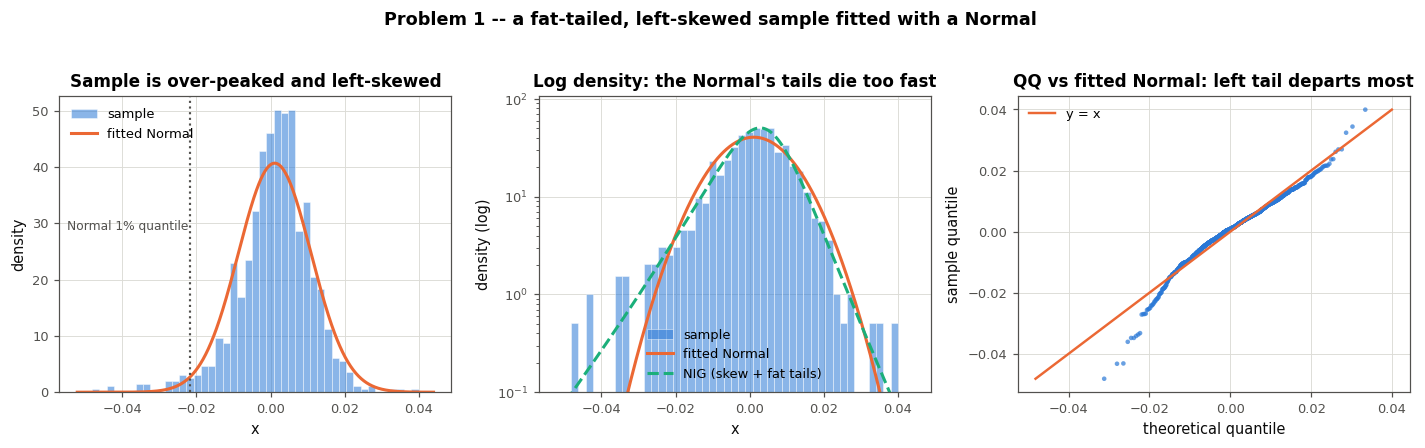

In [4]:
# (c) Locate the failure and its direction, then the likelihood comparison across
#     the Week 01 s5 families that s6 says is needed to choose among survivors.
problem1.part_c(x1, m1, fit1)

---

# Problem 2 — A Regression Whose Errors Are Not Normal

`problem2.csv` holds `x` and `y`, $n = 200$.

## Predict

### (a) What the scatter shows, and the expected error distribution

A strong, clean, positively-sloped linear relationship — no curvature, no fanning
of the spread as $x$ moves, so the functional form is not in question. What stands
out is a handful of points far off the line while the bulk sit tightly around it.

To describe the error term without contaminating the description with the very
estimator under test, the code takes out a **Theil–Sen** (robust) line first and
examines residuals about it. Using OLS residuals would be mildly circular — OLS is
the procedure whose assumptions we are checking, and its line is itself pulled
around by the outliers.

Those robust residuals have:

- skewness $= -0.365$, about $2.1$ se below zero — mild, close enough to
  symmetric that I will not model a skew
- **excess kurtosis $= +3.637$**, about $10.5$ se above zero

**Prediction:** the error is symmetric but strongly **leptokurtic** — a
**Student's $t$** with low degrees of freedom. Week 01 §5.4 notes daily equity
returns "fit a $t$ with $\nu$ somewhere between 3 and 6 considerably better than
they fit any normal," which brackets the expectation. Made quantitative: a $t_\nu$
has excess kurtosis $6/(\nu-4)$, so matching moments,

$$\frac{6}{\nu - 4} = 3.637 \quad\Longrightarrow\quad \nu \approx 5.65$$

**With a caveat recorded before fitting.** That formula needs $\nu > 4$ for the
population fourth moment to exist. Week 01 §3.3 is explicit that moments can be
infinite and that "the sample estimate will still come back as a finite number" —
so if the true $\nu$ is below 4, the sample kurtosis is not estimating anything
finite and will *understate* the tail weight, biasing this estimate upward in
$\nu$. So $\nu \approx 5.65$ is a rough **upper bound**, and I expect the MLE at or
below it. The outliers are not mistakes to remove; they are draws from a
heavy-tailed law.

### (b) The violated OLS assumption, and its predicted consequences

Week 02 §3.1 lists seven assumptions. The violated one is **#7, "the error term is
normally distributed."** The others hold: #1 linearity (no curvature), #4
uncorrelated errors (Durbin–Watson $= 2.016$), #5 constant variance (no fanning),
#6 cannot fail with one regressor.

§3.1 states exactly what breaking #7 costs: it "can be broken, however, if
assumed, then hypothesis testing along with confidence and prediction intervals
can be calculated." So the casualty is the **intervals**, not the point estimate.

**Predicted effect on $\beta$: almost none.** Normality is not needed for OLS to be
unbiased — Week 02 §3.3 derives $\hat\beta$ from least squares with no
distributional assumption, and §4 notes OLS and MLE "agree under normality and
part company as soon as we leave it." So $\hat\beta$ should land close to the
$t$-MLE's estimate. It will be *inefficient* — squared-error loss gives quadratic
weight to outliers — but not biased.

**Predicted effect on se$(\beta)$: inflated and unreliable.** The OLS standard
error is built from $\hat\sigma^2 = \text{SSR}/(n-2)$, which the squared large
residuals drive up. I expect roughly 15–25% inflation, and unreliable in a second
sense: the $t$-interval around it assumes normal errors.

**Summary: the slope survives, the standard error does not, and the quantiles of
the error distribution are where the real damage is.**


Problem 2(a,b) -- what the scatter shows before fitting
  Robust (Theil-Sen) line, used only as a fit-free probe:
    slope = 3.0180, intercept = 1.4879
  Moments of the residuals about that robust line:
    sd              = 1.3483
    skewness        = -0.3650  (-2.1 se from 0)
    excess kurtosis = +3.6371  (+10.5 se from 0)
  Roughly symmetric, strongly leptokurtic -> a Student t error is the
  natural guess. The kurtosis is what rules out the Normal.

  Moment-matched prediction for nu: a t_nu has excess kurtosis
  6/(nu-4) for nu > 4, so setting 6/(nu-4) = 3.6371 gives
    nu ~= 5.65
  CAVEAT worth recording before the fit: that formula requires nu > 4
  for the population 4th moment to exist at all. If the true nu is
  below 4, the sample kurtosis is not estimating a finite quantity
  and this estimate is unreliable -- biased DOWNWARD in tail weight,
  i.e. it will over-state nu. So 5.6 should be read as an upper
  bound on nu rather than a point prediction.

  Durbin-Watson on

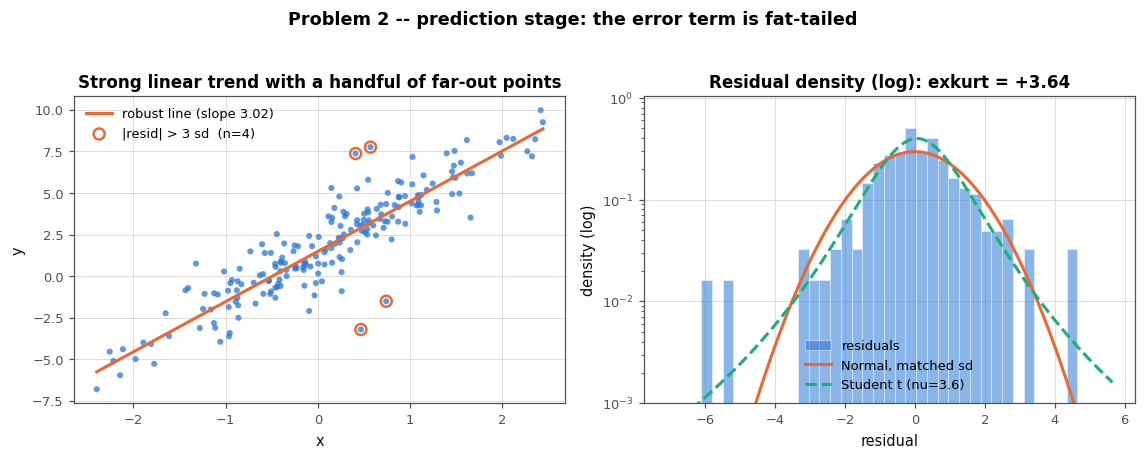

In [5]:
# (a),(b) Prediction stage. The probe uses a robust (Theil-Sen) line so the
# description of the error term does not depend on OLS itself. Also prints the
# moment-matched nu with its existence caveat, and the Durbin-Watson statistic.
d2 = common.load("problem2")
x2_, y2_ = d2["x"].to_numpy(), d2["y"].to_numpy()
problem2.part_ab(x2_, y2_)

## Fit

Three models on the same data:

1. **OLS** with conventional standard errors.
2. **MLE under a Normal error** — Week 02 §4.2 gives this log-likelihood.
3. **MLE under a Student's $t$ error** — with $(y_i-\alpha-\beta x_i)/s \sim t_\nu$,
   so $s$ is a *scale*, not the error sd. The implied sd is $s\sqrt{\nu/(\nu-2)}$,
   which is what compares against the Normal's $\sigma$. $\nu$ is bounded below at
   $2.01$ so the variance stays finite and that comparison stays meaningful.

Week 02 §5.3 fixes the parameter count: $k = p + d$, where $p$ includes the
intercept and $d$ is the number of extra distribution parameters fitted by MLE.
The slide's own worked case is a normal-error regression with $d=1$ for the fitted
variance, so $k = 3$ here; the $t$ adds $\nu$, giving $k = 4$.

MLE standard errors come from inverting a numerically differentiated Hessian of the
negative log-likelihood (observed information), computed explicitly in
`problem2.py` so the source of every reported se is visible.

### Results

| | $\alpha$ | $\beta$ | error parameters | $\ell$ | $k$ | AICc |
|---|---|---|---|---|---|---|
| **OLS** | 1.5607 (0.0963) | 2.9908 (0.0966) | $\hat\sigma = 1.3514$ | $-343.01$ | 3 | 692.14 |
| **MLE Normal** | 1.5607 (0.0958) | 2.9908 (0.0962) | $\hat\sigma = 1.3446$ | $-343.01$ | 3 | 692.14 |
| **MLE Student $t$** | 1.5480 (0.0807) | **3.0192** (0.0787) | $s = 0.9355$, $\nu = 3.63$ | $-328.56$ | 4 | **665.33** |

Two things to note:

- **OLS and MLE-Normal agree to four decimals on both coefficients.** Not a
  coincidence — maximising a Normal likelihood *is* minimising the sum of squares.
  They differ only in $\hat\sigma$, because OLS uses the unbiased
  $\text{SSR}/(n-2)$ while the MLE divides by $n$.
- **The fitted $\nu = 3.63$ came in below the moment-matched $5.65$, and below 4.**
  The caveat was the operative half of that prediction: at $\nu = 3.63$ the
  population excess kurtosis is infinite, so the sample value of $3.637$ was never
  estimating a finite parameter and the inversion was bound to overstate $\nu$.
  Right about direction and about $5.65$ being a ceiling; wrong to name a value.
  Week 01 §3.3's warning was the relevant one.

**AICc selects the Student $t$ by 26.8 units.** Week 02 §5.3 cautions that
absolute AICc values mean nothing and only differences between models on the same
data are interpretable, which is why $\Delta$AICc is reported throughout. The $t$
buys 14.45 log-likelihood points for one extra parameter.

In [6]:
# Fit all three models and compare by AICc with k = p + d per Week 02 s5.3. OLS
# and MLE-Normal are the same model, so AICc lists them once (k=3).
F2 = problem2.fit_models(x2_, y2_)


Problem 2 -- Model 1: OLS
  alpha = 1.5607   (se 0.0963)
  beta  = 2.9908   (se 0.0966)
  sigma = 1.3514   [s^2 = SSR/(n-2), the unbiased form]
  R^2   = 0.8287
  95% CI for beta: [2.8002, 3.1813]

  HC3 robust standard errors, for comparison:
    se(beta): 0.0966 (conventional) -> 0.0807 (HC3),
    a 17% reduction.
  That is a substantial change, and it lands close to the t-MLE's
  se(beta) reported below. But the REASON is not heteroskedasticity:
    Breusch-Pagan on this data: LM = 0.078, p = 0.7798
    -> assumption #5 (constant variance) is NOT rejected.
  The mechanism is WHERE the outliers sit. A sandwich estimator
  weights squared residuals by leverage, and this sample's 4 largest
  residuals fall at CENTRAL x values (mean |x - xbar| = 0.427 against
  0.786 overall), i.e. at LOW leverage. So HC3 sees little
  error variance where the x-leverage is, and returns a smaller
  se(beta). That is a fact about this sample's geometry, not a
  correction of a variance trend.
  CRUCIALL


Problem 2 -- Model 3: MLE, Student t error
  alpha = 1.5480   (se 0.0807)
  beta  = 3.0192   (se 0.0787)
  scale = 0.9355   (se 0.0847)
  nu    = 3.6322   (se 1.0011)
  implied error sd = scale*sqrt(nu/(nu-2)) = 1.3956
  log-likelihood = -328.5612

Problem 2 -- model choice by AICc
                  model   loglik  k    AICc  dAICc
     MLE Student t, k=4 -328.561  4 665.327  0.000
MLE Normal (= OLS), k=3 -343.011  3 692.145 26.817

  AICc prefers: MLE Student t, k=4, by 26.82 AICc units.
  The t buys 14.45 log-likelihood points for one extra
  parameter. A likelihood-ratio test of nu -> infinity is on the
  boundary, but 2*dLL = 28.9 against a chi2(1)
  critical value of 3.84 is not a close call.


## Reconcile

### (c) The three estimates of $\beta$

| model | $\beta$ | se$(\beta)$ | width of 95% CI |
|---|---|---|---|
| OLS | 2.9908 | 0.0966 | 0.3788 |
| MLE Normal | 2.9908 | 0.0962 | 0.3769 |
| MLE Student $t$ | 3.0192 | 0.0787 | 0.3084 |

**The violation moved the slope even less than predicted.** Total spread across the
three is $0.0284$, which is $0.29$ OLS standard errors — statistically
indistinguishable, all rounding to $\beta \approx 3.0$. My "almost none" was
directionally right but I would have accepted a larger discrepancy than occurred;
with $n = 200$ and few outliers, OLS's inefficiency had little room to show up in
the point estimate.

**The standard error moved as predicted, by close to the predicted amount.**
se$(\beta)$ falls from $0.0966$ to $0.0787$, an 18.6% reduction, inside the 15–25%
range. The $t$ likelihood gives bounded influence to a large residual, so outliers
no longer inflate estimated dispersion. The $t$'s interval for $\beta$ is 18.6%
narrower — OLS is not *wrong* about $\beta$, just needlessly imprecise.

**What HC3 does and does not repair.** Sandwich standard errors are the reflex
response to "my standard errors look wrong," so it is worth being precise. HC3
gives se$(\beta) = 0.0807$ against the conventional $0.0966$ — a 17% reduction,
landing close to the $t$-MLE's $0.0787$. But the reason is **not**
heteroskedasticity: Breusch–Pagan on this data gives $p = 0.7798$, so assumption
#5 (constant variance) is not rejected. The mechanism is *where* the outliers sit.
A sandwich estimator weights squared residuals by leverage, and this sample's four
largest residuals fall at central $x$ values (mean $|x - \bar x| = 0.427$ against
$0.786$ overall) — that is, at low leverage. So HC3 sees little error variance
where the $x$-leverage is and returns a smaller se. That is a fact about this
sample's geometry, not a correction of a variance trend.

Crucially, HC3 leaves $\hat\sigma$ and therefore the **fitted error distribution**
untouched; it re-weights the covariance of $\hat\beta$ only. The 99.5% error
quantile stays the Normal one, so the tail understatement quantified in part (e)
survives HC3 entirely. Robust standard errors fix inference on $\beta$; they do not
fix the density, which is where the risk number comes from. That is the case for
the $t$ model rather than an OLS-plus-robust-errors patch.

### (d) What the rejected model gets wrong, if not the slope

The **conditional density**, not its centre. It locates the line correctly and then
describes the spread around it incorrectly.

The Normal must set $\hat\sigma = 1.3446$ to accommodate the few large residuals,
because under squared-error loss those points are expensive to leave unexplained.
That single $\sigma$ then applies to *every* observation, asserting a spread of
$\pm 1.34$ for ordinary points that actually sit within about $\pm 0.94$ (the $t$'s
scale). The Normal is **too wide for the 95% of points that are well behaved and
too narrow for the 5% that are not.** It has one parameter for two different jobs;
the $t$'s $\nu$ is exactly the parameter that separates them.

The likelihood decomposition makes it precise: of the 14.45 log-likelihood points
the $t$ gains, **8.88 (61%) come from the 10 largest-residual observations.** The
Normal's error is concentrated in the tail — where a risk model's answer matters.
AICc is detecting a density failure invisible in the coefficient table.

### (e) Quantiles of the two fitted error distributions

| $p$ | fitted Normal | fitted $t$ | ratio $t$/Normal | wider |
|---|---|---|---|---|
| 90.0% | 1.7232 | 1.4629 | 0.85 | Normal |
| **95.0%** | **2.2117** | **2.0538** | **0.93** | **Normal** |
| 97.5% | 2.6354 | 2.7045 | 1.03 | $t$ |
| 99.0% | 3.1281 | 3.7098 | 1.19 | $t$ |
| **99.5%** | **3.4635** | **4.6201** | **1.33** | **$t$** |

The curves **cross at $p = 0.9703$.** Below it the Normal is wider; above it the
$t$ is.

**Why this must happen.** Both were fitted to the same data and must account for
the same total dispersion — variances are close ($1.34$ vs an implied $1.40$). But
they distribute that fixed budget differently. The $t$ places a large share in the
far tails, so with the total constrained it must be **tighter through the body** —
hence narrower at 95%. The Normal has no far tail available: $\phi(z)$ decays like
$e^{-z^2/2}$, so it cannot represent a 4-sigma event as anything but essentially
impossible. Its only route to accommodating the outliers is inflating $\sigma$,
which widens the *entire* distribution including the middle. So the Normal is wider
where most of the data is and narrower exactly where the risk is. The crossover is
forced by the variance constraint, not an artefact of these estimates.

**Which one for a capital buffer: the $t$, without hesitation.**

Buffers are set at 99% and beyond — Basel market-risk rules use 99%, and stressed
VaR and expected shortfall push further. There the $t$ is 18.6% to 33.4% wider, and
the gap grows with confidence. The Normal would set a buffer roughly a quarter too
small at 99.5% and fail in precisely the scenario the buffer exists for. Its
apparent "conservatism" at 95% is worthless by comparison: being over-capitalised
against routine fluctuations costs a little carry; being under-capitalised against
the tail is what ends firms. The choice is not close on fit grounds either — AICc
prefers the $t$ by 26.8 — so prudence and model quality point the same way.

A caveat: $\hat\nu = 3.63$ has a standard error of about $1.0$, so the degrees of
freedom are not tightly pinned down. Lower $\nu$ means fatter tails, so uncertainty
runs both ways and the 99.5% quantile is an estimate with real error bars. The
direction of the conclusion is robust; its magnitude is not.


Problem 2(c) -- the three slope estimates
  model                           beta   se(beta)   width of 95% CI
  -----------------------------------------------------------------
  OLS                           2.9908     0.0966            0.3788
  MLE Normal                    2.9908     0.0962            0.3769
  MLE Student t                 3.0192     0.0787            0.3084
  -----------------------------------------------------------------
  Spread across the three betas = 0.0284, which is 0.29 OLS standard errors.
  se(beta) falls from 0.0966 (OLS) to 0.0787 (t),
  a 18.6% reduction: the t
  down-weights the outliers instead of letting them inflate s^2.

Problem 2(d) -- what the rejected model gets wrong
  Not the slope. The Normal recovers beta = 2.9908 against
  the t's 3.0192. What it gets wrong is the DENSITY:
    * it must set sigma = 1.3446 to cover the outliers,
      which inflates the assumed spread of every ordinary point;
    * per-observation log-likelihood is -1.71

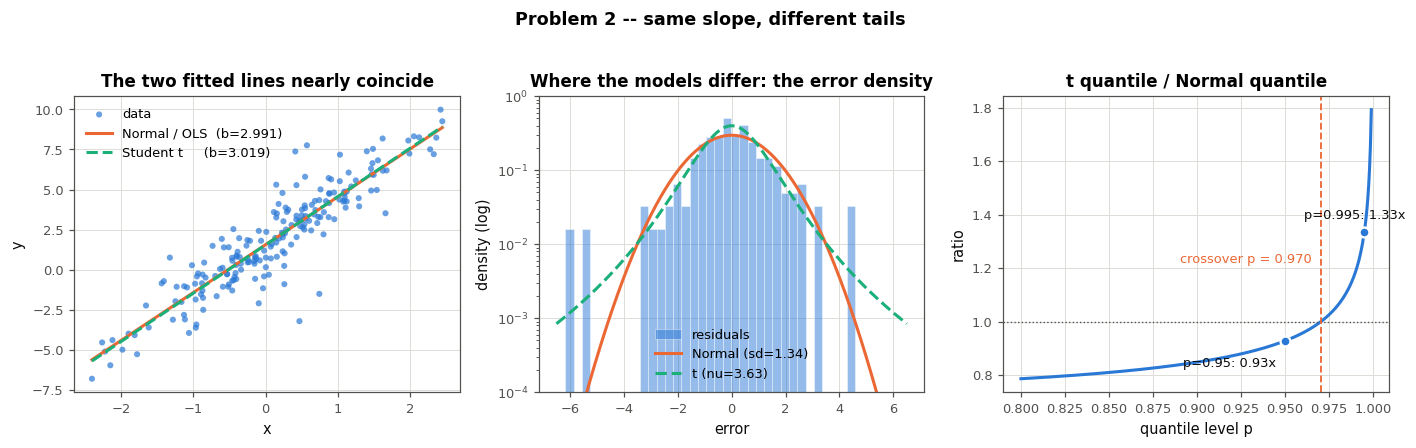

In [7]:
# (c),(d),(e) Compare the three slopes, decompose the likelihood gain by
# observation, and compare the two fitted error laws' quantiles.
problem2.reconcile(x2_, y2_, F2)

---

# Problem 3 — Pearson Against Spearman

`problem3.csv` holds four series `x1`–`x4`, $n = 500$.

## Predict

### (a) Which pair will disagree, which will agree, and why

Week 02 §1.3 defines Pearson as the covariance scaled into $[-1,1]$ — a moment
statistic. §1.4 defines Spearman as "the Pearson coefficient computed on ranks.
Nothing more than that," making it a measure of **monotonicity**. They therefore
diverge under two conditions: a monotone non-linearity, or extreme values dragging
the covariance.

Per-series moments locate the suspect before either matrix is computed:

| series | sd | skew | excess kurtosis |
|---|---|---|---|
| `x1` | 1.011 | 0.079 | 0.039 |
| **`x2`** | **3.894** | **0.907** | **21.992** |
| `x3` | 0.984 | −0.118 | 0.330 |
| `x4` | 0.967 | 0.247 | −0.035 |

`x1`, `x3`, `x4` are indistinguishable from Gaussian in shape. `x2` has excess
kurtosis $+22.0$, an sd four times the others, and values to $\pm 34$ against
$\pm 3$. Both divergence conditions point at `x2`.

The pair plot sharpens it: the `x1`–`x2` panel is not a noisy ellipse but a clean,
steep **S-curve** — flat through the middle, rising sharply at both ends. That is
an odd power function, and it is monotone.

**Predictions, committed:**

- **Largest disagreement: `x1`–`x2`.** Nearly deterministic and strictly
  increasing, so Spearman should be near $1$; badly non-linear, so Pearson must
  come in well below. I expect a gap of roughly $0.15$–$0.20$.
- **Second: `x2`–`x3`**, inheriting curvature at one remove.
- **Close agreement on `x1`–`x3`**: both Gaussian-looking, panel is a linear
  ellipse. Where the relationship really is linear and the marginals Normal, both
  coefficients estimate the same population quantity. I expect Spearman marginally
  *below* Pearson — the small efficiency loss from discarding the values.
- **Close agreement on all `x4` pairs**: `x4` looks independent; both should read
  $\approx 0$, and neither can manufacture association.


Problem 3(a) -- prediction stage: shape of each series
  series         sd     skew    exkurt      min      max
  -------------------------------------------------------
  x1          1.011    0.079     0.039   -2.959    3.228
  x2          3.894    0.907    21.992  -25.834   33.638
  x3          0.984   -0.118     0.330   -3.293    3.607
  x4          0.967    0.247    -0.035   -2.388    2.959
  -------------------------------------------------------
  x2 stands out: excess kurtosis ~ +22.0 and an sd roughly 4x the
  others. Any pair involving x2 is a candidate for disagreement,
  because Pearson is a moment statistic and x2's moments are
  dominated by a few extreme values.


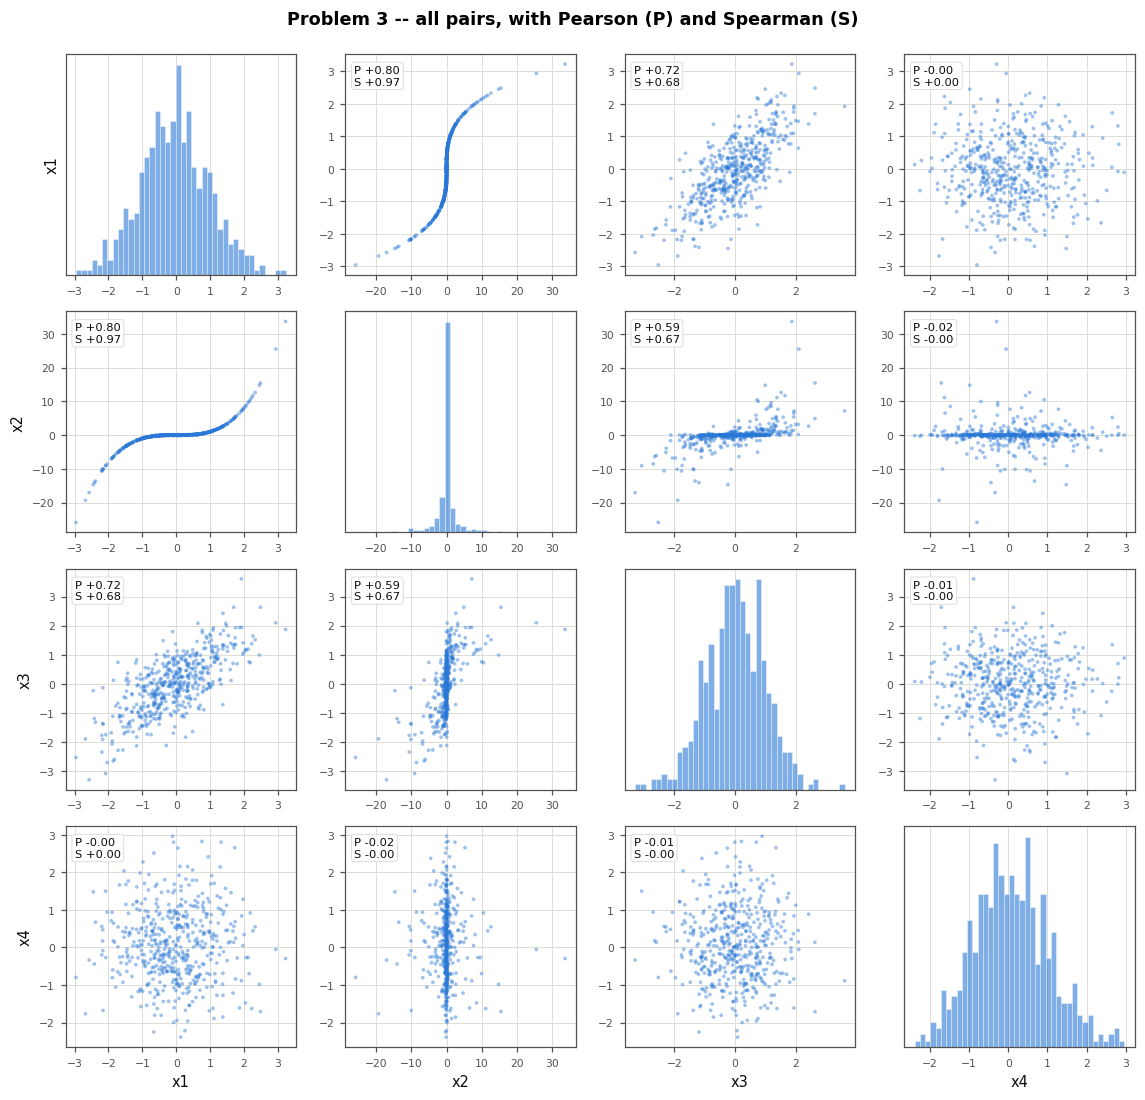

In [8]:
# (a) Prediction stage: per-series moments, then the full pair plot with both
# coefficients annotated on every panel so the prediction is checkable by eye.
d3 = common.load("problem3")
problem3.part_a(d3)

## Fit and reconcile

### (b) Both correlation matrices, and the largest gap

**Pearson**

| | x1 | x2 | x3 | x4 |
|---|---|---|---|---|
| **x1** | 1.0000 | 0.7991 | 0.7195 | −0.0047 |
| **x2** | 0.7991 | 1.0000 | 0.5876 | −0.0209 |
| **x3** | 0.7195 | 0.5876 | 1.0000 | −0.0086 |
| **x4** | −0.0047 | −0.0209 | −0.0086 | 1.0000 |

**Spearman**

| | x1 | x2 | x3 | x4 |
|---|---|---|---|---|
| **x1** | 1.0000 | 0.9719 | 0.6839 | 0.0002 |
| **x2** | 0.9719 | 1.0000 | 0.6674 | −0.0011 |
| **x3** | 0.6839 | 0.6674 | 1.0000 | −0.0024 |
| **x4** | 0.0002 | −0.0011 | −0.0024 | 1.0000 |

Ranked by absolute gap:

| pair | Pearson | Spearman | gap (S − P) |
|---|---|---|---|
| **`x1`–`x2`** | **+0.7991** | **+0.9719** | **+0.1728** |
| `x2`–`x3` | +0.5876 | +0.6674 | +0.0798 |
| `x1`–`x3` | +0.7195 | +0.6839 | −0.0356 |
| `x2`–`x4` | −0.0209 | −0.0011 | +0.0198 |
| `x3`–`x4` | −0.0086 | −0.0024 | +0.0062 |
| `x1`–`x4` | −0.0047 | +0.0002 | +0.0049 |

**Largest gap: `x1`–`x2`, Pearson $0.7991$ against Spearman $0.9719$, a gap of
$+0.1728$.**

Every prediction held, including the runner-up ordering, the sign of the small
`x1`–`x3` discrepancy, and the null results on `x4`.

In [9]:
# (b) Both correlation matrices and the ranked gap table.
gaps3 = problem3.part_b(d3)


Problem 3(b) -- the two correlation matrices
  PEARSON (linear association, uses the values)
        x1      x2      x3      x4
x1  1.0000  0.7991  0.7195 -0.0047
x2  0.7991  1.0000  0.5876 -0.0209
x3  0.7195  0.5876  1.0000 -0.0086
x4 -0.0047 -0.0209 -0.0086  1.0000

  SPEARMAN (monotone association, uses only the ranks)
        x1      x2      x3      x4
x1  1.0000  0.9719  0.6839  0.0002
x2  0.9719  1.0000  0.6674 -0.0011
x3  0.6839  0.6674  1.0000 -0.0024
x4  0.0002 -0.0011 -0.0024  1.0000

  All six pairs, ranked by |Spearman - Pearson|
 pair  pearson  spearman  gap (S - P)  abs gap
x1-x2  +0.7991   +0.9719      +0.1728  +0.1728
x2-x3  +0.5876   +0.6674      +0.0798  +0.0798
x1-x3  +0.7195   +0.6839      -0.0356  +0.0356
x2-x4  -0.0209   -0.0011      +0.0198  +0.0198
x3-x4  -0.0086   -0.0024      +0.0062  +0.0062
x1-x4  -0.0047   +0.0002      +0.0049  +0.0049

  LARGEST GAP: x1-x2 -- Pearson +0.7991 vs
  Spearman +0.9719, a gap of +0.1728.


### (c) The mechanism, and which coefficient is honest

**`x2` is essentially `x1` cubed.** Regressing `x2` on `x1`$^3$:

$$\texttt{x2} = -0.0023 + 0.9994\,\texttt{x1}^3, \qquad R^2 = 0.999834$$

with residual sd $0.050$.

**This is Week 02 §1.4 Figure 2 almost exactly.** The slide plots $y = x^3$ and
reports "Pearson is 0.74 but Spearman is 1.00 because the relationship is
monotonic." We get $0.80$ and $0.97$ on the same functional form, the differences
coming from this sample's noise and its particular spread of `x1`. The mechanism:

- $u \mapsto u^3$ is **strictly increasing**, so order is preserved almost
  perfectly and Spearman reads $0.9719$.
- The same map is **badly non-linear**. The best straight line through an S-curve
  is too steep through the flat middle and too shallow at the ends, so Pearson
  reads $0.7991$.

**Leverage.** `x2` has 12 observations beyond three sd, where a Normal gives about
one in 500. Dropping those twelve moves Pearson $0.7991 \to 0.8507$ — a shift of
$+0.05$ from 2.4% of the data — while Spearman barely moves, $0.9719 \to 0.9698$.
Pearson is a function of the sample covariance and is levered by extreme values;
Spearman sees only queue position.

**Why Spearman is $0.972$ and not exactly $1.000$.** The shortfall comes from the
*local flatness* of the cubic near the origin: the derivative $3x_1^2$ is $0.19$ at
$x_1 = 0.25$ against a noise sd of $0.050$. Where the local slope is comparable to
the noise, the noise decides the ordering. Mean absolute rank displacement is
$43.2$ for $|x_1| < 0.5$ but only $3.2$ outside it, and restricting to
$|x_1| \ge 0.5$ raises Spearman to $0.9985$. The middle panel shows this: the
orange points ($|x_1|<0.5$) are the only ones off the rank diagonal. A
local-flatness artefact, not evidence against the monotone story.

**Which coefficient is honest: Spearman.**

$0.9719$ truthfully describes the *dependence*. `x2` is an almost deterministic,
strictly increasing function of `x1`: learn `x1` and you know almost exactly where
`x2` sits. Reporting "0.80" invites the reader to think 36% of `x2`'s behaviour is
unexplained by `x1`, when essentially none is.

**But Pearson is not wrong — it answers a different question:** how much of `x2`'s
variance a straight line in `x1` explains. $0.7991$ is the correct answer to that,
and $0.7991^2 = 0.64$ is exactly the $R^2$ of a linear regression of `x2` on `x1`.
The failure is in the question. Week 02 §1.3's companion warning is the extreme
case: for $y = x^2$ Pearson is *exactly zero* though $y$ is deterministic in $x$ —
"a correlation of zero means no linear relationship. It does not mean no
relationship, and it does not mean independence." Our pair is the milder version:
monotone, so Pearson is large but still understated. §1.4 notes the converse *does*
hold for the multivariate normal, which is why zero correlation is safe to read as
independence there and nowhere else.

This has real consequences. Rank correlation is invariant to monotone re-scaling of
the marginals, which is why copula methods are built on it — §1.4 flags exactly
this: "Spearman returns in Week 05 ... rank correlation is the natural way to
describe dependence once the marginals have been stripped out." A portfolio model
estimating Pearson on raw positions with non-linear payoffs (options, say) would
understate co-movement and overstate diversification in the way seen here.

For the agreeing pairs the reading is the mirror image. On `x1`–`x3` the
relationship really is linear with Gaussian-looking marginals, both coefficients
estimate the same parameter, and Spearman's slight shortfall ($0.6839$ vs
$0.7195$) is the expected efficiency cost of discarding the values. When both
agree, that agreement is itself information: no monotone non-linearity and no
leverage points.


Problem 3(c) -- the mechanism behind the x1-x2 gap
  Test of a cubic link: regress x2 on x1^3
    x2 = -0.0023 + 0.9994 * x1^3
    R^2 = 0.999834,  residual sd = 0.0502
  So x2 is very nearly x1 cubed plus a little noise.

  This is Week 02 s1.4 Figure 2 almost exactly. The slide plots
  y = x^3 and reports 'Pearson is 0.74 but Spearman is 1.00 because
  the relationship is monotonic'. We get 0.80 and 0.97 on the
  same functional form, the small differences coming from this
  sample's noise and its particular spread of x1 values.

  That single fact explains the whole gap:
    * the map x -> x^3 is strictly increasing, so RANKS are almost
      perfectly preserved -> Spearman 0.9719, near 1;
    * but it is badly non-linear, so a straight line through the
      cloud misses -> Pearson only 0.7991.

  Leverage check -- x2 has 12 points beyond
  3 sd (a Normal would give ~1 in 500). Dropping just those:
    Pearson  0.7991 -> 0.8507
    Spearman 0.9719 -> 0.9698  (barely moves)
  Pears

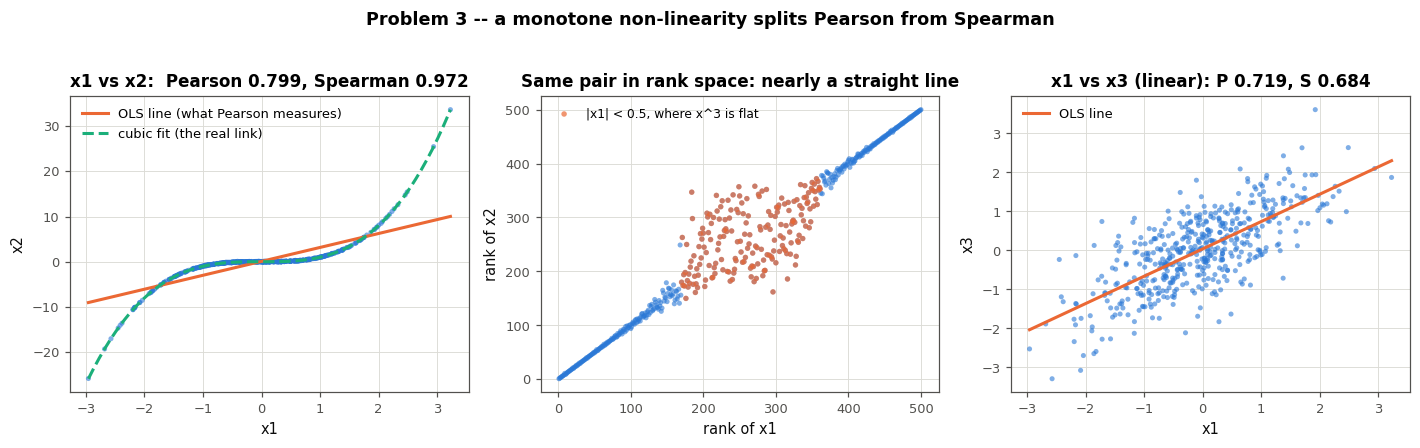

In [10]:
# (c) Establish the cubic mechanism, quantify the leverage, explain why Spearman
# falls just short of 1.0, and contrast with the pairs that agree.
problem3.part_c(d3, gaps3)

---

# Problem 4 — Conditional Distributions

`problem4.csv` holds two correlated series `x1` and `x2`, $n = 1000$.

## Predict

The sample covariance matrix, in the CSV's own order, and nothing else yet:

$$\begin{bmatrix} \operatorname{Var}(x_1) & \operatorname{Cov} \\ \operatorname{Cov} & \operatorname{Var}(x_2)\end{bmatrix}
= \begin{bmatrix} 1.09988 & 1.69690 \\ 1.69690 & 4.10475 \end{bmatrix},
\qquad \rho = 0.79862$$

### (a) Conditional variance of $x_2$ given $x_1$, in blocks of $\Sigma$

**Which series is which block — and the direction matters.** Week 02 §2.4
partitions $X = [x_1 ; x_2]$, conditions on the **second** block (given $X_2 = a$)
and returns the distribution of the **first**:

$$\bar\mu = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(a - \mu_2), \qquad
\bar\Sigma = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$

We want $x_2$ *given* $x_1$, so the variable we learn — the CSV's `x1` — must sit in
the slides' **second** block. Mapping this data onto the slide notation, the
partition is $[x_2 ; x_1]$, **not** $[x_1 ; x_2]$:

| slide block | this data | role |
|---|---|---|
| $\Sigma_{11} = \operatorname{Var}(x_2) = 4.10475$ | CSV `x2` | **target** — what we want the distribution of |
| $\Sigma_{22} = \operatorname{Var}(x_1) = 1.09988$ | CSV `x1` | **conditioning** — what we learn |
| $\Sigma_{12} = \operatorname{Cov}(x_2, x_1) = 1.69690$ | cross block | |

Getting this backwards still produces a number, and on a $2\times2$ problem a
plausible-looking one, so the mapping is stated rather than left to inference.

$$\operatorname{Var}(x_2 \mid x_1) = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}
= 4.10475 - \frac{1.69690^2}{1.09988} = 1.48675$$

so the conditional sd is $\sqrt{1.48675} = 1.21932$.

**The variance-reduction factor**, as a formula in the same blocks:

$$\frac{\operatorname{Var}(x_2 \mid x_1)}{\operatorname{Var}(x_2)}
= 1 - \frac{\Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}}{\Sigma_{11}} = 1 - \rho^2$$

numerically $1 - 0.79862^2 = \mathbf{0.36220}$. So learning $x_1$ removes **63.8%
of the variance** of $x_2$.

Worth quoting in both units, since band widths scale with sd, not variance. In
**standard-deviation** terms uncertainty falls by $\sqrt{0.36220} = 0.60183$ — from
$2.0260$ to $1.21932$, a **39.8% reduction in sd**. Same fact, and the second
number is the one describing how much narrower our interval for $x_2$ becomes.

A sanity check §2.4 supplies: $\Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$ is positive
semi-definite, so "conditioning never increases variance." Here it is
$2.618 \ge 0$ and the variance falls.

### (b) Does that factor depend on the observed value of $x_1$?

**No.** From the formula alone:

$$\operatorname{Var}(x_2 \mid x_1 = a) = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$

**The term that settles it is $\Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$** — a product
of covariance blocks with no $a$ in it. The observed value enters the conditional
*mean* and nowhere else. §2.4 says the same in words: the conditional variance "does
not depend on $a$ at all, so learning the value of $X_2$ reduces the uncertainty in
$X_1$ by the same amount regardless of what value showed up."

Two consequences:

1. The 95% band has **constant width** in $x_1$ — the conditional distribution is
   homoskedastic.
2. This is a **property of the multivariate Normal, not a general fact.** For a
   general joint distribution $\operatorname{Var}(x_2\mid x_1=a)$ can depend on $a$
   however it likes.

**Prediction for the coverage checks:** if $(x_1,x_2)$ really is bivariate Normal,
the band should contain about 95% overall *and* about 95% within every subset of
$x_1$, since the width was derived from an assumption holding pointwise. Flat
coverage across buckets is the testable implication.

In [11]:
# (a),(b) Prediction stage: only the covariance matrix is consulted. Block
# mapping follows Week 02 s2.4, which conditions on the SECOND block -- so the
# partition here is [x2 ; x1]. See the module docstring for why.
d4 = common.load("problem4")
x1_4, x2_4 = d4["x1"].to_numpy(), d4["x2"].to_numpy()
B4 = problem4.part_ab(x1_4, x2_4)


Problem 4(a) -- conditional variance of x2 given x1
  Sample covariance matrix, in the CSV's own [x1, x2] order:
    [[ 1.09988,  1.69690],
     [ 1.69690,  4.10475]]
    implied correlation rho = 0.79862

  WHICH SERIES IS WHICH BLOCK.
  Week 02 s2.4 conditions on the SECOND block and returns the
  distribution of the FIRST. We want x2 GIVEN x1, so x1 has to be the
  second block. The partition is therefore [x2 ; x1]:
    Sigma_11 = Var(x2)     = 4.10475   <- TARGET (block 1)
    Sigma_22 = Var(x1)     = 1.09988   <- CONDITIONING (block 2)
    Sigma_12 = Cov(x2, x1) = 1.69690   <- cross block

  Week 02 s2.4 partitioned result, as written on the slide:
    Var(x2 | x1) = Sigma_11 - Sigma_12 Sigma_22^{-1} Sigma_21
                 = 4.10475 - (1.69690)^2 / 1.09988
                 = 1.48675      (conditional sd = 1.21932)

  VARIANCE-REDUCTION FACTOR, as a formula in the same blocks:
    Var(x2|x1) / Var(x2)
        = 1 - Sigma_12 Sigma_22^{-1} Sigma_21 / Sigma_11
        = 1 - rho^2


## Fit and reconcile

### (c) Conditional mean, the coefficient, and the band

$$E[x_2 \mid x_1 = a] = \text{mean}(x_2) + \Sigma_{12}\Sigma_{22}^{-1}(a - \text{mean}(x_1))
= 0.04529 + 1.54281\,(a + 0.01671)$$

**The coefficient on $x_1$ is $\Sigma_{12}\Sigma_{22}^{-1} = 1.54281$.**

**In regression terms this is exactly the OLS slope of $x_2$ on $x_1$.** The code
confirms it: `OLS slope = 1.54281`, identical, with intercept $0.07107 =
\text{mean}(x_2) - \beta\,\text{mean}(x_1)$. Week 02 §2.4 states this directly —
"The expression for $\bar\mu$ is a regression. $\Sigma_{12}\Sigma_{22}^{-1}$ is the
matrix of coefficients from regressing $X_1$ on $X_2$" — and §3 then derives the
same quantity from least squares instead. Conditioning a bivariate Normal and
running a regression are the same computation.

The 95% band is

$$E[x_2\mid x_1] \pm 1.95996 \times 1.21932 = E[x_2\mid x_1] \pm 2.38983$$

of **constant width**, as (b) requires.

One convention, since it changes (d): this is a **prediction band for a new
observation**, not a confidence band for the fitted line. The question asks what
fraction of *observations* fall inside, so the band must be the one observations are
supposed to fall into. (A confidence band for the mean would be narrower by roughly
$\sqrt{n}$ and contain almost no observations.) The multiplier is $1.95996$, not 2.

### (d) Fraction of observations inside the band

**935 of 1000 — coverage $= 0.9350$.**

Short of nominal by 1.5 points. With a binomial se of $0.0069$ that is $2.2$ se
below nominal: detectable, but the kind of miss one might attribute to the Normal
being an approximation. On its own this looks like a model that basically works.

That impression is wrong, and (e) shows it.

### (e) Coverage within each $|x_1 - \mu_1|$ bucket

| bucket | $n$ | coverage | residual sd |
|---|---|---|---|
| $\lvert x_1 - \mu_1\rvert \le 1\,\text{sd}$ | 759 | **0.9565** | 1.0758 |
| $1\,\text{sd} < \cdot \le 2\,\text{sd}$ | 190 | **0.8579** | 1.5804 |
| $\cdot > 2\,\text{sd}$ | 51 | **0.9020** | 1.5957 |
| *pooled* | *1000* | *0.9350* | *1.2193* |

Coverage is **not flat**: $0.9565$ in the centre, $0.8579$ in the middle ring,
$0.9020$ in the far tail. The centre **over-covers**, the wings **under-cover**.

Note what the pooled figure did. 76% of the data sits in the central bucket where
the band over-covers, partially offsetting the wings' deficit. The aggregate
$0.9350$ averages two opposite errors and conceals both. **A global calibration
check can pass while the model is mis-calibrated everywhere.**

In [12]:
# (c),(d),(e),(f) Conditional mean, the 95% prediction band, overall coverage,
# bucketed coverage, and the heteroskedasticity diagnosis.
R4 = problem4.part_cde(x1_4, x2_4, B4)


Problem 4(c) -- conditional mean of x2 given x1
  Week 02 s2.4, in the same [x2 ; x1] blocks as part (a):
    E[x2 | x1 = a] = mu_2 + Sigma_12 Sigma_22^{-1} (a - mu_1)
  (slide block 1 is x2, so the slide's mu_1 is this data's mean of x2;
   renaming to match the CSV to avoid confusion:)
    E[x2 | x1 = a] = mean(x2) + Sigma_12 Sigma_22^{-1} (a - mean(x1))
                   = 0.04529 + (1.69690 / 1.09988) (a - -0.01671)
                   = 0.04529 + 1.54281 (a - -0.01671)

  THE COEFFICIENT ON x1 is Sigma_12 Sigma_22^{-1} = 1.54281.
  In regression terms this is exactly the OLS slope of x2 on x1:
    OLS slope     = 1.54281   (identical, as it must be)
    OLS intercept = 0.07107  = mu_2 - beta*mu_1 = 0.07107
  So 'conditioning a bivariate Normal' and 'running a regression'
  are the same computation; the partitioned formula is where the
  regression coefficient comes from. Week 02 s2.4 says so directly:
  'The expression for mubar is a regression. Sigma_12 Sigma_22^-1 is
  the matr

### (f) What the non-flat coverage tells us, and which assumption failed

**About the data:** the conditional variance of $x_2$ is **not constant in $x_1$** —
it grows with $|x_1|$. Residual sd runs $1.076$ centrally against $1.580$ and
$1.596$ outside, a 48% increase. Binned finer, it climbs from about $0.94$ near the
centre to about $1.71$ in the tails, straddling the single $1.219$ the band
assumes. The band is built from an average of a quantity varying by nearly $2\times$.

| test | statistic | $p$ |
|---|---|---|
| Breusch–Pagan (linear in $x_1$) | $\text{LM} = 4.669$ | $0.0307$ |
| White (allows $x_1^2$) | $\text{LM} = 84.205$ | $2.237 \times 10^{-17}$ |

The contrast is itself informative. Breusch–Pagan is only marginal because it
regresses squared residuals on $x_1$ *linearly*, and the variance is not monotone in
$x_1$ — it is **symmetric in $|x_1|$**, high at both ends. A linear-in-$x_1$ test is
nearly blind to a U shape, since the two sides largely cancel. White includes
$x_1^2$ and sees it. Had I run only Breusch–Pagan I would have recorded a borderline
result and quite possibly moved on.

**The assumption that failed: homoskedasticity of the conditional distribution —
equivalently, joint normality of $(x_1,x_2)$.** In Week 02 §3.1's numbering this is
assumption **#5**, "the error term has a constant variance." (§3.1 also notes §7 of
that deck handles its relaxation, via GARCH.)

Two views of one failure. Part (b) established that a bivariate Normal *must* have
$\operatorname{Var}(x_2\mid x_1)$ free of $x_1$, because the formula contains no
$a$. The data violate that, so the pair is **not jointly Normal** — whatever the
marginals look like. Worth stressing: both marginals can pass a univariate
normality check while the joint fails. Normal marginals do not imply a Normal joint.
The constant-width band inherits the error exactly.

### Which parts of (c) survive, and which do not

**Survives — the conditional mean.** $\beta = \Sigma_{12}\Sigma_{22}^{-1} = 1.54281$
remains the **best linear predictor** of $x_2$ given $x_1$, a characterisation
depending only on second moments — on $\Sigma$ being what it is. It needs neither
normality nor homoskedasticity. Week 02 §3.3 derives the same quantity from least
squares with no distributional assumption, which is why it is untouched. The line is
still right, OLS still estimates it without bias.

**Does not survive — everything about the width.**

- $\operatorname{Var}(x_2\mid x_1) = 1.48675$ is not wrong as an average, but it is
  only an average. There is no single conditional variance; treating it as one is
  the error.
- The constant-width band is mis-calibrated pointwise, delivering its nominal 95%
  nowhere.
- The claim in (b) that the factor is independent of $x_1$ was a correct deduction
  *from the Normal model* and a false statement *about this data*.
- se$(\beta)$ from OLS is not trustworthy: $0.03680$ conventional against $0.05564$
  HC3, a 51% understatement.

**The direction of the risk is the dangerous one.** The band is too narrow exactly
where $x_1$ is extreme — the stress scenarios. Such a model looks well-behaved
backtested against ordinary days, because that is where it over-covers, and
understates outcomes precisely when conditions are extreme.

**Fixes, increasing in commitment:** HC3 robust standard errors if only inference on
$\beta$ is needed; a variance function or WLS if the band must be right; a
GARCH-type specification if this is a time series with clustering (Week 02 §7); or a
copula for the full joint law. The first is a one-line change and already worth
making.

### Reconciliation

**This is the one prediction of the five that failed, so it is worth being precise
about which half.**

| predicted in (a)/(b) | outcome |
|---|---|
| reduction factor $=1-\rho^2 = 0.3622$ | **correct** — algebra, not an empirical claim |
| the factor does not depend on observed $x_1$ | **correct as a deduction from the Normal**, false as a description of this data |
| coverage $\approx 95\%$ overall | **near enough** — $0.9350$, about $2.2$ se low |
| **coverage $\approx 95\%$ within every bucket** | **wrong** — $0.9565 / 0.8579 / 0.9020$ |

The derivation was sound. What I failed to do was **check that the Normal applied
before reasoning inside it.** I confirmed $x_1$ and $x_2$ were correlated, read off
$\Sigma$, and treated a model-conditional result as a fact about the data.

**What I had missed:** joint normality is a much stronger claim than a covariance
matrix can support, and nothing I looked at would have revealed the difference — a
covariance matrix is compatible with *any* joint distribution having those second
moments, including strongly heteroskedastic ones. Had I plotted residual spread
against $x_1$ before committing — available at the prediction stage, needing only
the regression line — the fanning would have been obvious.

The overall $0.9350$ deserves particular blame for how plausible it looks. Weighted
76% toward the central bucket where the band over-covers, the centre's excess
partially cancels the wings' deficit. A single aggregate number here did not merely
fail to inform; it actively pointed the wrong way.

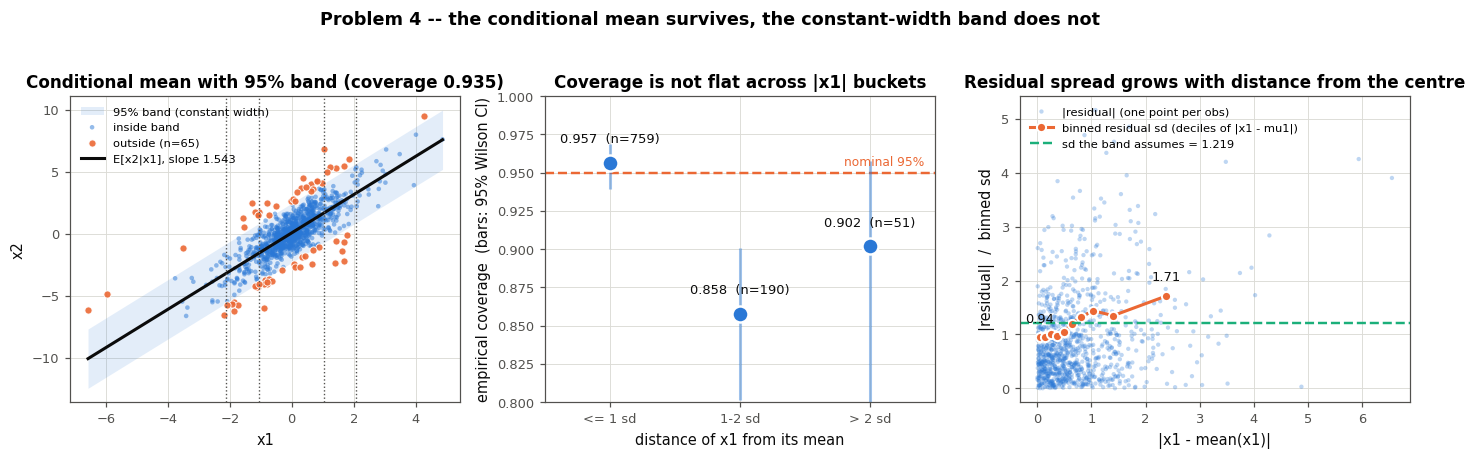

In [13]:
# Figures for Problem 4: the band over the scatter with out-of-band points ringed,
# bucketed coverage with Wilson intervals, and the binned residual sd.
problem4.figures(x1_4, x2_4, B4, R4)

---

# Problem 5 — Identifying an AR or MA Order

`problem5.csv` holds a single series `x`, $n = 500$. (The time-series material is in
the Week 02 deck, §6.)

## Predict

The series is stationary and mean-reverting with no trend or obvious variance
change — an augmented Dickey–Fuller test gives $\text{stat} = -7.271$,
$p = 1.59\times10^{-10}$, so we identify on the levels without differencing.

### (b) The rule, and the significance band

Taking (b) first, since the rule is what makes (a) an argument rather than a guess.
Week 02 §6.1 Table 3:

| process | ACF | PACF |
|---|---|---|
| MA($q$) | cuts off after lag $q$ | decays |
| AR($p$) | decays | cuts off after lag $p$ |
| ARMA($p,q$) | decays | decays |

§6.1 defines the PACF as "the autocorrelation of the residual of the series
regressed on the $n-1$ lags," which is what makes the cut-off argument work, and
notes "Table 3 is the reason both functions are reported together. Either one alone
is ambiguous."

**Why the rule works.** The PACF at lag $k$ is the coefficient on $x_{t-k}$ in a
regression *already containing* lags $1\ldots k-1$. An AR($p$) is by construction a
regression on exactly $p$ lags, so past $p$ there is nothing left to add and the
PACF is zero, while its ACF decays geometrically — §6.3 derives $\rho(k)=\beta^k$
for the AR(1). An MA($q$) is the mirror: a finite sum of $q+1$ shocks, so
observations more than $q$ apart share none and the ACF is exactly zero past $q$.

**The band: $\pm 1.96/\sqrt{n} = \pm 0.0877$**, the Bartlett band under the null of
**white noise** — the right reference for a "cuts off" judgement, since cutting off
after lag $q$ means lags beyond $q$ are indistinguishable from zero.

### (a) Which function cuts off, which decays, and the implied order

| lag | ACF | outside band? | PACF | outside band? |
|---|---|---|---|---|
| 1 | $+0.4616$ | yes | $+0.4616$ | yes |
| 2 | $-0.0254$ | . | $\mathbf{-0.3031}$ | **yes** |
| 3 | $-0.1657$ | yes | $-0.0147$ | . |
| 4 | $-0.1104$ | yes | $-0.0169$ | . |
| 5 | $-0.0841$ | . | $-0.0843$ | . |
| 6 | $-0.0405$ | . | $+0.0159$ | . |
| 7 | $-0.0193$ | . | $-0.0381$ | . |
| 8 | $-0.0469$ | . | $-0.0632$ | . |
| 9 | $+0.0446$ | . | $+0.1264$ | yes |
| 10 | $+0.1321$ | yes | $+0.0435$ | . |

**The PACF cuts off; the ACF decays.**

The PACF is large at lags 1 ($+0.462$) and 2 ($-0.303$), then inside the band at lag
3 ($-0.015$) and staying there through lag 8. A drop of $20\times$ is a genuine
cut-off, not a decay.

The ACF does not cut off: $+0.462$, $-0.025$, $-0.166$, $-0.110$, $-0.084$,
$-0.041$ — tapering while changing sign. That sign change is diagnostic: a **damped
oscillation** signals an AR with a *negative* second coefficient. §6.3's AR(1) ACF
is $\beta^k$, monotone when $\beta>0$, so the flips require a second-order term and
are not something a low-order MA produces.

**Prediction, committed: AR(2)**, with $\phi_1 > 0$ and $\phi_2 < 0$.

**One caveat recorded up front.** Three coefficients poke just outside the band at
long lags: PACF lag 9 ($+0.1264$), ACF lag 10 ($+0.1321$) and ACF lag 11 ($+0.0925$).
The table above is abridged to the first 10 lags; the module prints all 15, and the
full lists are ACF outside at lags $\{1,3,4,10,11\}$ and PACF outside at
$\{1,2,9\}$.

Testing 15 lags at the 5% level gives $0.75$ expected false positives, so three
marginal exceedances is more than the point estimate but well inside what noise
produces — and none of them has a mechanism behind it. I am not reading them as
structure, for two reasons stated now rather than after seeing the AICc: they are
isolated rather than forming a decaying pattern, and no AR or MA order in the
candidate set can absorb an isolated lag-10/11 spike without adding several
parameters that nothing pays for. Part (e)'s Ljung–Box check returns to this and
finds the same lag-10 residual, which I report rather than round away.


Problem 5(a,b) -- reading the ACF and PACF
  n = 500, mean = 0.6709, sd = 1.1211
  ADF test for a unit root: stat = -7.271, p = 1.59e-10
  -> stationary, so no differencing; identify on the levels.

  Significance band used for the 'cuts off' call:
    +/- 1.96/sqrt(n) = +/- 0.0877   (Bartlett, H0 = white noise)

   lag       ACF  |ACF|>band      PACF  |PACF|>band
  --------------------------------------------------
     1    0.4616         yes    0.4616          yes
     2   -0.0254           .   -0.3031          yes
     3   -0.1657         yes   -0.0147            .
     4   -0.1104         yes   -0.0169            .
     5   -0.0841           .   -0.0843            .
     6   -0.0405           .    0.0159            .
     7   -0.0193           .   -0.0381            .
     8   -0.0469           .   -0.0632            .
     9    0.0446           .    0.1264          yes
    10    0.1321         yes    0.0435            .
    11    0.0925         yes   -0.0153            .
    12 

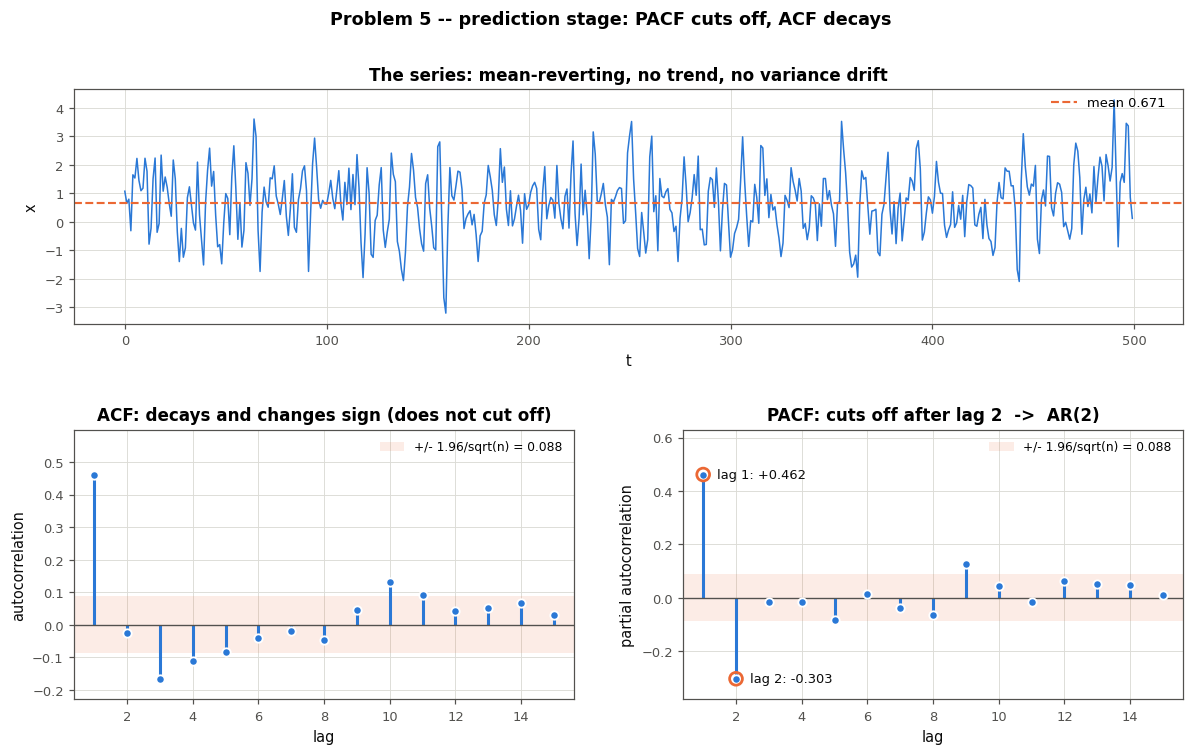

In [14]:
# (a),(b) Identification: ADF test, ACF and PACF against the white-noise band,
# and the series plot, following Week 02 s6.1 Table 3.
x5 = common.load("problem5")["x"].to_numpy()
ident5 = problem5.part_ab(x5)

## Fit and reconcile

### (c) AICc for all six models

All six fitted by exact MLE on the levels with an intercept. Per Week 02 §5.3,
$k = p + d$ counts the intercept, the AR/MA coefficients, and $\sigma^2$ — so AR(2)
has $k = 4$, not 2.

| model | $\ell$ | $k$ | AICc | $\Delta$AICc | $R^2$ |
|---|---|---|---|---|---|
| **AR(2)** | $-682.179$ | 4 | **1372.438** | **0.000** | 0.285730 |
| MA(3) | $-681.998$ | 5 | 1374.117 | 1.678 | 0.286225 |
| AR(3) | $-682.111$ | 5 | 1374.343 | 1.905 | 0.285925 |
| MA(2) | $-686.575$ | 4 | 1381.232 | 8.794 | 0.273015 |
| MA(1) | $-691.518$ | 3 | 1389.084 | 16.646 | 0.258399 |
| AR(1) | $-706.269$ | 3 | 1418.587 | 46.149 | 0.213206 |

Fitted AR(2): $\hat\phi_1 = +0.6012$, $\hat\phi_2 = -0.3026$,
$\hat\sigma^2 = 0.8958$, intercept $0.6706$.

### (d) What AICc selects, and whether it matched

**AICc selects AR(2), matching the prediction** — including the signs,
$\hat\phi_1 = +0.60$ and $\hat\phi_2 = -0.30$, as the oscillating ACF implied.

Reading the margins:

- **Every AR beats the MA of the same order** — the ACF/PACF diagnosis reappearing
  in the likelihood, and the cleanest confirmation that the family call was right
  independent of the order call.
- **AR(1) is 46 AICc units behind.** It cannot generate a negative lag-2 partial
  autocorrelation at all, so it is structurally incapable, not merely worse.
- **MA(3) is second at $\Delta$AICc $= 1.68$**, inside the range usually called
  indistinguishable. This deserves an honest note. §6.3 shows an AR(1) back-
  substitutes into an infinite MA — "This is a special case of an infinite moving
  average" — and the same holds for the AR(2), so three MA terms approximate it
  fairly well. AR(2) wins by doing marginally *better* with one *fewer* parameter.
  If fit alone decided, the choice would be close; parsimony separates them. I would
  still report AR(2) — it is preferred, more compact, and the PACF cut-off gives an
  independent structural reason to prefer the AR family — but I would not claim the
  margin over MA(3) is decisive. The margin over AR(3), which (e) asks about, is a
  different matter.

### (e) AR(2) against AR(3)

| | AR(2) | AR(3) |
|---|---|---|
| log-likelihood | $-682.1788$ | $-682.1109$ |
| $k$ | 4 | 5 |
| AICc | **1372.4383** | 1374.3432 |
| $R^2$ | 0.285730 | **0.285925** |
| $\hat\sigma^2$ | 0.895802 | 0.895558 |

The third coefficient is $\hat\phi_3 = -0.0165$ with se $0.0438$: $t = -0.38$,
$p = 0.71$, 95% interval $[-0.102, +0.069]$ covering zero comfortably.
Indistinguishable from noise.

**What AICc is trading off.** With
$\text{AICc} = -2\ell + 2k + \frac{2k^2+2k}{n-k-1}$, moving AR(2) $\to$ AR(3):

- **gains** $\Delta\ell = 0.0679$, so $-2\ell$ improves by only $0.1357$;
- **costs** $2.0406$ in penalty as $k$ goes $4 \to 5$.

Net: AICc **rises by $1.9049$** and the larger model is rejected. The rule of thumb
is that one extra parameter must earn about **1 unit of log-likelihood** to pay for
itself; this earned $0.0679$, about 7% of its cost.

What is really being priced is **estimation variance against approximation bias**.
Adding $\phi_3$ removes negligible bias — there is no lag-3 structure — while adding
a parameter's worth of estimation noise that degrades out-of-sample prediction.

**Why $R^2$ would not make the same choice.**

$R^2$ *rises*, $0.285730 \to 0.285925$ — a gain of $1.95\times10^{-4}$. Tiny, but
**positive**, and the sign is the point.

Week 02 §5.1 states the defect directly: "The biggest problem with $R^2$ is that as
variables are added, it continuously increases, regardless if they are explanatory,"
and "Adding a column of random numbers to any regression raises the $R^2$." An $R^2$
of 1.0 reached that way "describes the sample perfectly and forecasts nothing at
all." Structurally: $R^2 = 1 - \text{SS}_{error}/\text{SS}_{total}$ is monotone in
the residual sum of squares, and adding a parameter to a least-squares fit can never
*increase* SSR — at worst the optimiser sets the new coefficient to zero. So $R^2$ is
weakly increasing in model size **by construction**, with no term charging for a
parameter, and it cannot express "this improvement is too small to be worth a
parameter." Handed this comparison it would take AR(3) over AR(2), and AR(50) over
AR(3), to a model with as many parameters as observations.

$R^2$ measures in-sample fit; AICc estimates out-of-sample predictive loss. Only the
second can decline a free improvement in fit. **Adjusted $R^2$** (§5.2) does add a
penalty — the $(n-1)/(n-p-1)$ factor — but a much weaker one, and it is framed for
nested least-squares models rather than comparing an AR against an MA. §5.3 offers
AICc for that job and supplies the reason to prefer it over plain AIC here: "In
small sample sizes, AIC can tend to select models with higher numbers of parameters
and overfitting of the model, in the same way $R^2$ does."

**Adequacy of the selected model.** A selection criterion only ranks the candidates
offered; it cannot say the winner is good. Ljung–Box on the AR(2) residuals
(`model_df=2`, correcting the dof for the fitted AR terms) gives $p = 0.245$ at lag
5, $p = 0.042$ at lag 10, $p = 0.101$ at lag 15.

I report the lag-10 value rather than rounding it away: it is marginally below
$0.05$, and traces to the lag-10 ACF spike flagged in (a). Two reasons not to chase
it: three lag-windows at 5% makes one marginal rejection unsurprising, and no order
in the candidate set fixes an isolated lag-10 spike without several unpriced
parameters. The honest reading is that **AR(2) is adequate over lags 1–5, where the
structure is, with a marginal residual at lag 10 I am not modelling** — rather than
the cleaner but overstated claim that the residuals are white.

In [15]:
# (c),(d) Fit AR(1..3) and MA(1..3) and report AICc for each, with k = p + d.
F5 = problem5.part_cd(x5)


Problem 5(c) -- AICc for the six candidate models
  All six are fitted with an intercept ('c' trend), by exact MLE on
  the levels. k counts every estimated parameter: the intercept, the
  AR/MA coefficients, and sigma^2. So AR(2) has k = 4, not 2.



model    loglik  k      AICc   dAICc       R2   sigma2
AR(2) -682.1788  4 1372.4383  0.0000 0.285730 0.895802
MA(3) -681.9975  5 1374.1165  1.6782 0.286225 0.895105
AR(3) -682.1109  5 1374.3432  1.9049 0.285925 0.895558
MA(2) -686.5754  4 1381.2316  8.7933 0.273015 0.911749
MA(1) -691.5179  3 1389.0843 16.6460 0.258399 0.930102
AR(1) -706.2693  3 1418.5870 46.1486 0.213206 0.986801

  Fitted coefficients of each model:
    AR(1): const=+0.6707, ar.L1=+0.4611, sigma2=+0.9868
    AR(2): const=+0.6706, ar.L1=+0.6012, ar.L2=-0.3026, sigma2=+0.8958
    AR(3): const=+0.6705, ar.L1=+0.5962, ar.L2=-0.2927, ar.L3=-0.0165, sigma2=+0.8956
    MA(1): const=+0.6713, ma.L1=+0.5296, sigma2=+0.9301
    MA(2): const=+0.6710, ma.L1=+0.6314, ma.L2=+0.1615, sigma2=+0.9117
    MA(3): const=+0.6709, ma.L1=+0.5931, ma.L2=+0.0648, ma.L3=-0.1555, sigma2=+0.8951

Problem 5(d) -- what AICc selects
  AICc selects AR(2) (AICc = 1372.438).
  Runner-up: MA(3) at dAICc = 1.678.
  The prediction from part (a) was AR(2


Problem 5(e) -- AR(2) against AR(3)
                         AR(2)         AR(3)
  ------------------------------------------
  log-lik            -682.1788     -682.1109
  k                          4             5
  AICc               1372.4383     1374.3432
  R^2                 0.285730      0.285925
  sigma^2             0.895802      0.895558
  ------------------------------------------
  The third coefficient: phi3 = -0.0165 with se 0.0438
    t = -0.378, p = 0.706 -- indistinguishable
    from zero. Its 95% CI, [-0.102, +0.069], covers 0 comfortably.

  WHAT AICc IS TRADING OFF:
    AICc = -2*loglik + 2k + 2k(k+1)/(n-k-1).
    Going AR(2) -> AR(3) buys dloglik = 0.0679, so the fit term
    -2*loglik improves by only 0.1357.
    The penalty term rises by 2.0406
    (k goes 4 -> 5). The penalty wins, so AICc RISES by 1.9049
    and the larger model is rejected.
    The rule of thumb behind the arithmetic: one extra parameter has
    to earn about 1 unit of log-likelihood to pay 

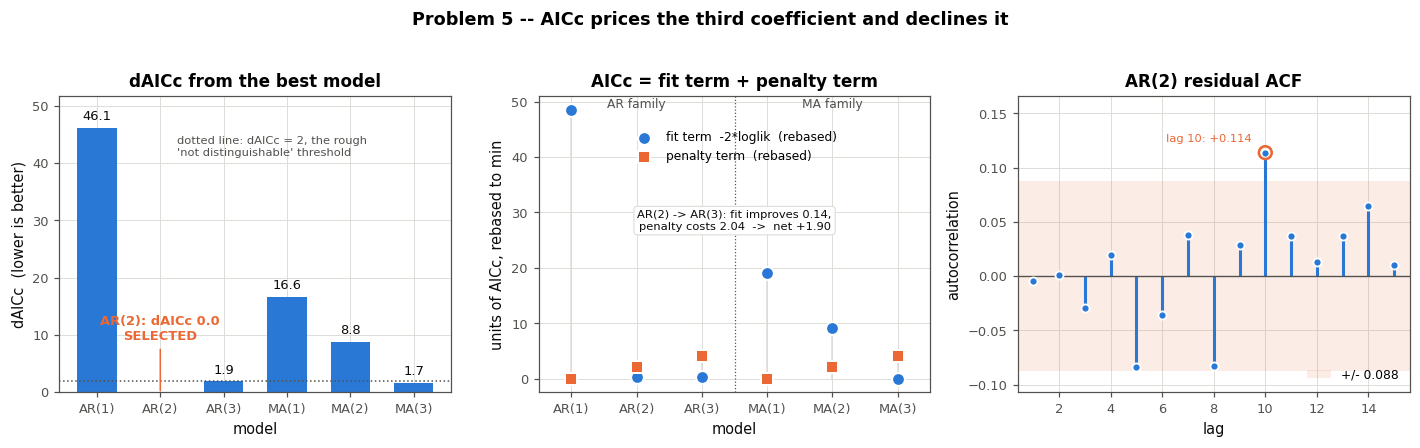

In [16]:
# (e) The AR(2) vs AR(3) trade-off, the R^2 contrast per Week 02 s5.1-5.3, and a
# Ljung-Box adequacy check on the selected model's residuals.
problem5.part_e(x5, F5)

---

# Summary

| problem | prediction | fit | matched? |
|---|---|---|---|
| **1** | Left-skewed, fat-tailed; Table 6 row "skew $\ne0$, exkurt $>0$" $\Rightarrow$ NIG; Normal and Lognormal impossible, symmetric $t$ a near-miss; $>10$ below the Normal's 1% quantile | skew $-0.670$, exkurt $+2.358$; NIG best by AICc, $\beta<0$ as required; **26** below vs **10** expected | **Yes**, family and direction. Missed the *thin right* tail and the over-peaked centre |
| **2** | Assumption #7 violated; $t$ errors, moment-matched $\nu\approx5.65$ flagged as an upper bound; slope barely moves, se inflated 15–25% | $\nu = 3.63$; $\beta$ spread $0.29$ se; se falls 18.6%; AICc favours $t$ by $26.8$ | **Yes** on the slope and the se. The $\nu$ estimate was too high, exactly as its caveat warned |
| **3** | `x1`–`x2` largest gap from monotone non-linearity; `x1`–`x3` agree; `x4` null | gap $+0.173$; mechanism is $x_2 \approx x_1^3$, $R^2 = 0.9998$ — Week 02 Figure 2 | **Yes**, including runner-up ordering and the sign of the `x1`–`x3` gap |
| **4** | Factor $1-\rho^2$, independent of observed $x_1$; coverage flat at 95% | factor $0.362$; coverage $0.935$ overall but $0.957/0.858/0.902$ by bucket | **Factor: yes. Flat coverage: no.** Heteroskedastic, so not jointly Normal |
| **5** | PACF cuts off after lag 2, ACF decays $\Rightarrow$ AR(2), $\phi_2<0$ | AICc selects AR(2); $\phi_1 = +0.601$, $\phi_2 = -0.303$ | **Yes**, including the sign of $\phi_2$ |

## The predictions that missed, and what they taught

Two missed, and only one was a real error of reasoning.

**The minor miss — Problem 2's $\nu$.** The moment-matched $\nu \approx 5.65$ came in
above the fitted $3.63$. But it was issued with an explicit caveat: the
$6/(\nu-4)$ inversion needs $\nu > 4$ for the fourth moment to exist, so the estimate
was an upper bound. That caveat was the operative half — at $\nu = 3.63$ the
population excess kurtosis is infinite and the sample $3.637$ was never estimating
anything finite. Week 01 §3.3 had already warned that a sample estimate of a
non-existent moment "will still come back as a finite number." The lesson is narrow
but worth keeping: **a moment-matching estimate is only as good as the existence of
the moment it matches.**

**The substantive failure — Problem 4(b).** The derivation was correct: under a
multivariate Normal $\operatorname{Var}(x_2\mid x_1)$ genuinely does not depend on
the observed value, and $\Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$ genuinely contains
no $a$. What I had not separated was **a correct deduction from a model** and **a
claim about the data.** I read off $\Sigma$ and then reasoned inside the Normal
without asking whether the Normal applied. The data are heteroskedastic —
conditional sd from about $0.94$ centrally to about $1.71$ in the tails — so the
pair is not jointly Normal, and the constant-width band is mis-calibrated everywhere
even though pooled coverage of $0.935$ looks nearly right.

Three things to carry forward:

1. **A global calibration check can pass while the model fails everywhere.** The
   pooled $0.935$ averaged over-coverage in the centre (76% of the data) against
   under-coverage in the wings. Only the bucketed check exposed it. Any backtest
   reported as a single number deserves this suspicion.
2. **Test the assumption you are about to rely on, and with the right test.**
   Breusch–Pagan returned a borderline $p = 0.031$ and would have let this pass;
   White's test, admitting $x_1^2$ and so able to see a variance symmetric in
   $|x_1|$, returned $p = 2.24\times10^{-17}$. The choice of test decided whether
   the failure was visible at all.
3. **Separate what a failure destroys from what it leaves standing.** The
   conditional *mean* survived: $\beta = \Sigma_{12}\Sigma_{22}^{-1} = 1.543$ is the
   best linear predictor on second moments alone, needing neither normality nor
   homoskedasticity. Everything about the *width* did not. After finding a violated
   assumption, partition the results rather than discarding them.

A thread runs through the other problems. In Problem 1 the Normal was exact to the
5% level and failed progressively from 2.5% inward. In Problem 2 all three models
agreed on the slope while disagreeing sharply at the 99.5% quantile — the number a
capital buffer is built from. In Problem 3 Pearson's $0.80$ was the correct answer to
a question nobody should ask of a cubic relationship. Each time the model was
adequate for the ordinary case, wrong about the extreme one, and the deficiency was
invisible in the headline statistic. That is the recurring shape of these failures,
and the reason risk work is done at the quantile rather than the mean.